<!-- STANDIN notebook title -->
# Part notebook: from explanations to rules, the BRB (steps D1–D5)

Owner: Stefanos. This title and the stand-in cells are dropped by `tools/assemble.py`.

In [1]:
# STANDIN A1-A3
%run 00_setup.ipynb

(11430, 89)
status
legitimate    5715
phishing      5715
Name: count, dtype: int64


6858 2286 2286
train      phishing share: 0.500
validation phishing share: 0.500
test       phishing share: 0.500


In [2]:
# STANDIN A6, B2, B5, B6
# Stand-ins copied from the lab: the forest (A6), its SHAP ranking shap_top (B2), the three URLs with
# i_wrong (B5) and the LIME import (B6). Dropped by tools/assemble.py; in the hand-in notebook the real
# steps provide them.
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from lime.lime_tabular import LimeTabularExplainer

rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

explainer = shap.TreeExplainer(rf)
sv1 = explainer(X_test.iloc[:500])[:, :, 1]
shap_top = pd.Series(np.abs(sv1.values).mean(axis=0),
                     index=X_test.columns).sort_values(ascending=False)

prob = rf.predict_proba(X_test)[:, 1]
pred = (prob >= 0.5).astype(int)
yt = y_test.values
wrong = np.where(yt != pred)[0]
i_wrong = wrong[np.argmax(np.abs(prob[wrong] - 0.5))]
print("stand-ins ready: top SHAP features", list(shap_top.index[:3]), "| i_wrong =", i_wrong)

stand-ins ready: top SHAP features ['google_index', 'page_rank', 'nb_hyperlinks'] | i_wrong = 1257


<!-- STEP D1 -->
# 8. Part D: From explanations to rules (BRB)

Now we take the two most important features and build a Belief Rule-Based expert system (BRB) with
them, the same way as in the BRB slides.

## Step D1: Choose your two features

We take the top of the forest's SHAP ranking (step B2), skipping 0/1 features like `google_index`,
because a BRB needs Low, Medium and High. We also check that each feature really gets three different
referential values (5th percentile < median < 95th percentile, as used in step D3): a feature with many
equal values could collapse two levels into one.

In [3]:
# STEP D1
# The BRB needs Low / Medium / High, so skip 0/1 features
ranked = [f for f in shap_top.index if X_train[f].nunique() > 2]
F1, F2 = ranked[0], ranked[1]         # you may change these

# Check: three different referential values from the training data (the same rule as in step D3)
def three_levels(f):
    r = X_train[f].quantile([0.05, 0.50, 0.95]).round(2).tolist()
    return r[0] < r[1] < r[2]

usable = [f for f in ranked if three_levels(f)]
if [F1, F2] != usable[:2]:
    print("skipped (two referential values are equal):",
          [f for f in ranked[:ranked.index(usable[1])] if f not in usable])
    F1, F2 = usable[0], usable[1]

skipped_binary = [f for f in shap_top.index[:ranked.index(F2) + 1] if f not in ranked]
print("0/1 features skipped:", skipped_binary)
print("Antecedents:", F1, "and", F2)

0/1 features skipped: ['google_index']
Antecedents: page_rank and nb_hyperlinks


<!-- STEP D1 -->
**Our two features.** The top of the SHAP ranking is `google_index`, a 0/1 feature, so it is skipped.
The next two both have three different referential values:

- **`page_rank`** (0–10): how well-linked the site is. Phishing sites are new and nobody links to them,
  so they usually score low (in the whole dataset, 96% of URLs with page rank 0 are phishing).
- **`nb_hyperlinks`**: how many links the page has. Phishing pages are often a single fake login form
  with very few links, while real sites link to many of their own pages.

Both are also in the top 5 of almost every list in step B4, so a BRB built on them uses clues that all
our models agree on.

<!-- STEP D2 -->
## Step D2: The BRB code

Step 1 splits a value between its two nearest reference values. Step 2 finds how strongly each of the
9 rules matches. Step 3 combines the rules with Evidential Reasoning, so the output also has an
**Unknown** part.

In [4]:
# STEP D2
# Step 1: input transformation (same as in the BRB slides)
def transform_to_belief(value, references):
    value = float(value)
    n = len(references)
    belief = [0.0] * n
    if value <= references[0]:
        belief[0] = 1.0
        return belief
    if value >= references[-1]:
        belief[-1] = 1.0
        return belief
    for i in range(n - 1):
        lower, upper = references[i], references[i + 1]
        if lower <= value <= upper:
            d = upper - lower
            belief[i] = (upper - value) / d
            belief[i + 1] = (value - lower) / d
            return belief
    return belief

# Step 2: rule activation weights (9 rules = 3 x 3)
def calculate_activation_weights(belief1, belief2):
    d1 = attribute_weights[0]
    d2 = attribute_weights[1]
    activation = []
    for i in range(3):
        for j in range(3):
            w = (rule_weights[i * 3 + j]
                 * belief1[i] ** d1 * belief2[j] ** d2)
            activation.append(w)
    total = sum(activation)
    if total == 0:
        return [0.0] * len(activation)
    return [x / total for x in activation]

# Step 3: Evidential Reasoning (ER)
def combine_two(b1, ig1, b2, ig2, n=3):
    conflict = sum(b1[i] * b2[j] for i in range(n)
                   for j in range(n) if i != j)
    k = 1 / (1 - conflict)
    new_b = [k * (b1[i] * b2[i] + b1[i] * ig2 + ig1 * b2[i])
             for i in range(n)]
    return new_b, k * (ig1 * ig2)

def er_aggregation(weights, rules, n=3):
    act = [(w, r) for w, r in zip(weights, rules) if w > 0]
    bel = [[w * v for v in r] for w, r in act]
    ign = [1 - sum(b) for b in bel]
    fb, fg = bel[0], ign[0]
    for i in range(1, len(bel)):
        fb, fg = combine_two(fb, fg, bel[i], ign[i], n)
    return fb, fg

def brbes_inference(v1, v2):
    belief1 = transform_to_belief(v1, refs1)
    belief2 = transform_to_belief(v2, refs2)
    aw = calculate_activation_weights(belief1, belief2)
    final_belief, ignorance = er_aggregation(aw, rules)
    return belief1, belief2, aw, final_belief, ignorance

<!-- STEP D3 -->
## Step D3: Referential values and the 9 rules

Low / Medium / High are the 5th percentile, median and 95th percentile of the **training** data. In
the slides an expert wrote the rules by hand; here we start from the data: for each rule we count how
many of the training URLs that match it are phishing (share 0 = Low risk, 0.5 = Medium, 1 = High).
The **support** says how much data stands behind each rule.

In [5]:
# STEP D3
# Referential values Low / Medium / High for each antecedent,
# taken from the TRAINING data: 5th percentile, median, 95th percentile
refs1 = X_train[F1].quantile([0.05, 0.50, 0.95]).round(2).tolist()
refs2 = X_train[F2].quantile([0.05, 0.50, 0.95]).round(2).tolist()
print(F1, "Low/Medium/High =", refs1)
print(F2, "Low/Medium/High =", refs2)

consequent_refs = ["Low", "Medium", "High"]   # consequent: phishing risk
attribute_weights = [1.0, 1.0]
rule_weights = [1.0] * 9

# Start the 9 rules from the training data.
# For each rule: how many of the URLs that activate it are phishing?
A = np.array([calculate_activation_weights(transform_to_belief(a, refs1),
                                           transform_to_belief(b, refs2))
              for a, b in X_train[[F1, F2]].values])      # (6858 URLs, 9 rules)
support = A.sum(axis=0)                                   # how much data per rule
phish = (A * y_train.values[:, None]).sum(axis=0)         # phishing part
share = phish / np.maximum(support, 1e-9)

# Turn each phishing share into beliefs in Low / Medium / High risk
# (share 0 -> Low, 0.5 -> Medium, 1 -> High), with the same Step 1 function
rules = [transform_to_belief(s, [0.0, 0.5, 1.0]) for s in share]

names = ["Low", "Med", "High"]
for k in range(9):
    i, j = k // 3, k % 3
    print(f"R{k + 1}: {F1}={names[i]:4s} {F2}={names[j]:4s} "
          f"-> {[round(x, 2) for x in rules[k]]}  (support {support[k]:.0f})")

# The rule table for the report
rule_table = pd.DataFrame({
    "rule": [f"R{k + 1}" for k in range(9)],
    F1: [["Low", "Medium", "High"][k // 3] for k in range(9)],
    F2: [["Low", "Medium", "High"][k % 3] for k in range(9)],
    "belief_Low": [round(r[0], 3) for r in rules],
    "belief_Medium": [round(r[1], 3) for r in rules],
    "belief_High": [round(r[2], 3) for r in rules],
    "phishing_share": share.round(3),
    "support": support.round(1),
})
rule_table.to_csv("results/tables/D3_rules.csv", index=False)

# A rule with (almost) no data gets share 0 and claims "Low risk" without evidence
thin = rule_table[rule_table["support"] < 20]
print("rules with support below 20:", "none" if thin.empty else list(thin["rule"]))

page_rank Low/Medium/High = [0.0, 3.0, 8.0]
nb_hyperlinks Low/Medium/High = [0.0, 33.0, 325.0]
R1: page_rank=Low  nb_hyperlinks=Low  -> [0.0, 0.11, 0.89]  (support 1106)
R2: page_rank=Low  nb_hyperlinks=Med  -> [0.0, 0.32, 0.68]  (support 960)
R3: page_rank=Low  nb_hyperlinks=High -> [0.0, 0.75, 0.25]  (support 141)
R4: page_rank=Med  nb_hyperlinks=Low  -> [0.0, 0.63, 0.37]  (support 854)
R5: page_rank=Med  nb_hyperlinks=Med  -> [0.43, 0.57, 0.0]  (support 1650)
R6: page_rank=Med  nb_hyperlinks=High -> [0.84, 0.16, 0.0]  (support 627)
R7: page_rank=High nb_hyperlinks=Low  -> [0.0, 0.77, 0.23]  (support 344)
R8: page_rank=High nb_hyperlinks=Med  -> [0.58, 0.42, 0.0]  (support 773)
R9: page_rank=High nb_hyperlinks=High -> [0.96, 0.04, 0.0]  (support 403)
rules with support below 20: none


In [6]:
# STEP D3
# Sanity checks of the engine (step D2) with these referential values
assert transform_to_belief(refs1[1], refs1) == [0.0, 1.0, 0.0]       # a level value: full belief
half = (refs1[0] + refs1[1]) / 2
assert np.allclose(transform_to_belief(half, refs1), [0.5, 0.5, 0.0])  # halfway: 0.5 / 0.5
assert np.allclose(A.sum(axis=1), 1.0)                                  # 9 weights sum to 1 per URL
b1, b2, aw, fb, ig = brbes_inference(X_train[F1].iloc[0], X_train[F2].iloc[0])
assert abs(sum(fb) + ig - 1) < 1e-9                                     # beliefs + Unknown = 1
print("engine sanity checks passed")

engine sanity checks passed


<!-- STEP D3 -->
**Do the rules make sense?** Yes, mostly:

- The two extremes are clear: R1 (low page rank, few links) → High risk 0.89, and R9 (high page rank,
  many links) → Low risk 0.96.
- Risk falls when either feature grows. With a Low page rank, High risk goes 0.89 → 0.68 → 0.25 as the
  links go Low → Medium → High, and with Low links it goes 0.89 → 0.37 → 0.23 as the page rank grows.
- No rule is empty: the smallest support is R3 with about 141 URLs, so no rule claims "Low risk"
  without data.
- The middle rules are uncertain: R5 (both Medium) is {Low 0.43, Medium 0.57}. Two features cannot
  separate those URLs well, which is why the BRB is much weaker than the full forest (step D4).

<!-- STEP D4 -->
## Step D4: Use the BRB as a phishing detector

`BRBDetector` turns the beliefs into one phishing score with the utility (Low = 0, Medium = 0.5,
High = 1), so `report()` works unchanged. For a fair comparison we also train a small tree and a
forest on the same two features.

In [7]:
# STEP D4
def brb_predict_proba(X):
    """X: array (n, 2) of [F1, F2].
    Returns (n, 4): Low, Medium, High, Unknown."""
    X = np.atleast_2d(X)
    out = []
    for v1, v2 in X:
        fb, ig = brbes_inference(v1, v2)[3:]
        out.append(fb + [ig])
    return np.array(out)

class BRBDetector:
    """Makes the BRB look like a scikit-learn model, so report() works."""
    def predict_proba(self, X):
        B = brb_predict_proba(X[[F1, F2]].values)
        # utility: Low = 0, Medium = 0.5, High = 1; Unknown is left out
        u = (0.5 * B[:, 1] + B[:, 2]) / (1 - B[:, 3])
        return np.column_stack([1 - u, u])
    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

brb = BRBDetector()

# Fair comparison: other models that see ONLY the same two features
from sklearn.tree import export_text
tree2 = DecisionTreeClassifier(max_depth=2, random_state=42)
tree2.fit(X_train[[F1, F2]], y_train)
rf2 = RandomForestClassifier(n_estimators=300, random_state=42,
                             n_jobs=-1)
rf2.fit(X_train[[F1, F2]], y_train)

print("BRB, 2 features   :", report(brb, X_test, y_test))
print("tree, 2 features  :", report(tree2, X_test[[F1, F2]], y_test))
print("forest, 2 features:", report(rf2, X_test[[F1, F2]], y_test))
print("forest, all 87    :", report(rf, X_test, y_test))

brb_scores = pd.DataFrame({
    "BRB, 2 features": report(brb, X_test, y_test),
    "tree (depth 2), 2 features": report(tree2, X_test[[F1, F2]], y_test),
    "forest, 2 features": report(rf2, X_test[[F1, F2]], y_test),
    "forest, all 87 features": report(rf, X_test, y_test),
}).T
brb_scores.index.name = "model"
brb_scores.to_csv("results/tables/D4_brb_scores.csv")
print("the depth-2 tree on the same two features:")
print(export_text(tree2, feature_names=[F1, F2]))
brb_scores

BRB, 2 features   : {'macro_F1': 0.802, 'recall': 0.773, 'ROC_AUC': 0.914, 'FAR': 0.169}
tree, 2 features  : {'macro_F1': 0.803, 'recall': 0.948, 'ROC_AUC': 0.885, 'FAR': 0.334}


forest, 2 features: {'macro_F1': 0.847, 'recall': 0.842, 'ROC_AUC': 0.927, 'FAR': 0.148}


forest, all 87    : {'macro_F1': 0.965, 'recall': 0.968, 'ROC_AUC': 0.994, 'FAR': 0.038}


the depth-2 tree on the same two features:
|--- nb_hyperlinks <= 51.50
|   |--- page_rank <= 1.50
|   |   |--- class: 1
|   |--- page_rank >  1.50
|   |   |--- class: 1
|--- nb_hyperlinks >  51.50
|   |--- page_rank <= 1.50
|   |   |--- class: 1
|   |--- page_rank >  1.50
|   |   |--- class: 0



,macro_F1,recall,ROC_AUC,FAR
model,,,,
"BRB, 2 features",0.802,0.773,0.914,0.169
"tree (depth 2), 2 features",0.803,0.948,0.885,0.334
"forest, 2 features",0.847,0.842,0.927,0.148
"forest, all 87 features",0.965,0.968,0.994,0.038


<!-- STEP D4 -->
**BRB vs the small tree.** Their macro-F1 is almost the same (0.802 against 0.803), as the lab
predicted, but they make very different mistakes:

- The **depth-2 tree** catches 94.8% of phishing but flags **33.4% of legitimate URLs**. Its rules show
  why: it only calls a URL legitimate when it has more than 51 links **and** a page rank above 1.5.
- The **BRB** catches 77.3% of phishing and flags 16.9% of legitimate URLs.

A security team would usually prefer the **BRB**. A filter that blocks one in three legitimate sites
floods the analysts with false alarms, and users learn to ignore it. The BRB's graded output
(Low/Medium/High + Unknown) also lets the team use a lower threshold, or send "Medium with high Unknown"
URLs to a human. Where a missed phishing site costs much more than a false alarm (e.g. a mail filter in
front of a bank), the tree's recall could win. Both are far below the full forest (0.965); the forest on
the same two features reaches 0.847, so a lot of information lives in the other 85 features.

<!-- STEP D5 -->
## Step D5: Explain one URL: the rules, LIME and SHAP

First the BRB explains itself: which rules fire for the forest's mistake from step B5, and how much is
Unknown. Then we treat the BRB as a black box, as in the slides, and explain its High-risk belief with
LIME and SHAP.

In [8]:
# STEP D5
# The BRB explains itself: which rules fire for the mistake from step B5?
url = X_test[[F1, F2]].iloc[i_wrong].values
b1, b2, aw, fb, ig = brbes_inference(*url)
print(F1, "=", url[0], "  ", F2, "=", url[1])
for k in range(9):
    if aw[k] > 0:
        print(f"   rule R{k + 1} fires with weight {aw[k]:.2f}"
              f"   (rule belief Low/Medium/High {[round(x, 2) for x in rules[k]]},"
              f" adds {aw[k] * rules[k][2]:.2f} High before ER)")
print("belief Low/Medium/High:", [round(x, 3) for x in fb])
print("Unknown:", round(ig, 3), "  true label:", y_test.iloc[i_wrong])
print("BRB phishing score:", round(float(brb.predict_proba(X_test.iloc[[i_wrong]])[0, 1]), 3))

page_rank = 2.0    nb_hyperlinks = 5.0
   rule R1 fires with weight 0.28   (rule belief Low/Medium/High [0.0, 0.11, 0.89], adds 0.25 High before ER)
   rule R2 fires with weight 0.05   (rule belief Low/Medium/High [0.0, 0.32, 0.68], adds 0.03 High before ER)
   rule R4 fires with weight 0.57   (rule belief Low/Medium/High [0.0, 0.63, 0.37], adds 0.21 High before ER)
   rule R5 fires with weight 0.10   (rule belief Low/Medium/High [0.43, 0.57, 0.0], adds 0.00 High before ER)
belief Low/Medium/High: [0.015, 0.333, 0.337]
Unknown: 0.315   true label: 0
BRB phishing score: 0.735


LIME (High): [('page_rank', -0.202576143550484), ('nb_hyperlinks', -0.17920134610547675)]
fit score  : 0.738


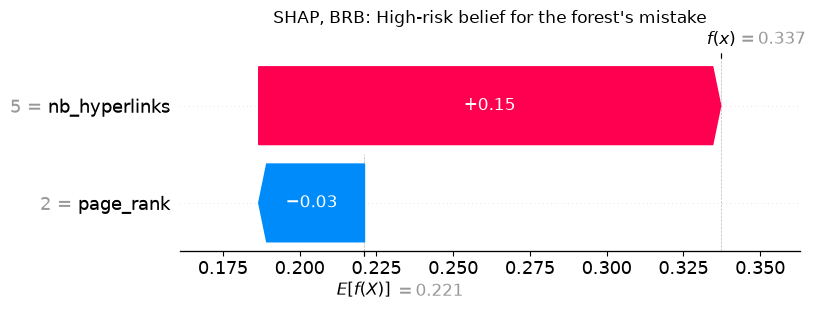

In [9]:
# STEP D5
feature_names = [F1, F2]
X_ref = X_train[[F1, F2]].values           # reference data for LIME and SHAP

brb_lime = LimeTabularExplainer(X_ref, feature_names=feature_names,
                                discretize_continuous=False,
                                random_state=42)
lime_exp = brb_lime.explain_instance(url, brb_predict_proba,
                                     labels=(2,),        # 2 = "High" risk
                                     num_features=2, num_samples=2000)
print("LIME (High):", lime_exp.as_list(label=2))
print("fit score  :", round(lime_exp.score, 3))

background = shap.sample(X_ref, 100, random_state=0)   # "ordinary" URLs
brb_shap = shap.KernelExplainer(brb_predict_proba, background)
sv_brb = brb_shap(url.reshape(1, -1), silent=True)   # silent: no progress bar
sv_brb.feature_names = feature_names
shap.plots.waterfall(sv_brb[0, :, 2], show=False)     # the "High" risk belief
plt.title("SHAP, BRB: High-risk belief for the forest's mistake")
plt.savefig("results/figures/D5_shap_brb_waterfall_high.png", dpi=150, bbox_inches="tight")
plt.show()

<!-- STEP D5 -->
**The expert's hand-edit.** As the lab suggests, we act as the expert and change one rule by hand:
R4 (`F1` Medium, `F2` Low) becomes {Low 0.0, Medium 0.2, High 0.8}. We rerun the D4 scores and the D5
trace with the edited rules, then put the data-driven rules back, so every later cell uses the rules
from step D3.

In [10]:
# STEP D5
rules_from_data = [list(r) for r in rules]
edited = [list(r) for r in rules]
edited[3] = [0.0, 0.2, 0.8]                          # R4, set by the "expert"
print("R4 from the data:", [round(x, 2) for x in rules_from_data[3]], "-> edited:", edited[3])
try:
    rules = edited
    print("BRB with the edited rule:", report(brb, X_test, y_test))
    fb_e, ig_e = brbes_inference(*url)[3:]
    print("mistake URL, belief Low/Medium/High:", [round(x, 3) for x in fb_e],
          " Unknown:", round(ig_e, 3))
finally:
    rules = rules_from_data                          # back to the data-driven rules
print("BRB with the data rules :", report(brb, X_test, y_test))

R4 from the data: [0.0, 0.63, 0.37] -> edited: [0.0, 0.2, 0.8]


BRB with the edited rule: {'macro_F1': 0.818, 'recall': 0.818, 'ROC_AUC': 0.905, 'FAR': 0.183}
mistake URL, belief Low/Medium/High: [0.014, 0.128, 0.557]  Unknown: 0.3


BRB with the data rules : {'macro_F1': 0.802, 'recall': 0.773, 'ROC_AUC': 0.914, 'FAR': 0.169}


<!-- STEP D5 -->
**What we see**

- **Was the BRB fooled too? Yes.** For `graphicsfairy.blogspot.ru` (legitimate) the BRB gives High 0.337,
  Medium 0.333, Low 0.015 and **Unknown 0.315**, a phishing score of 0.735. With only 5 links
  (near the Low level 0) and page rank 2 (between Low 0 and Medium 3), it looks like a phishing page to
  the rules too. The large Unknown part shows that the firing rules disagree.
- **Which rule is most to blame?** R4 (page rank Medium, links Low) fires the strongest (weight 0.57),
  but R1 (page rank Low, links Low, High 0.89) adds the most High-risk belief (0.25, against 0.21 from R4).
  Both have "few links" in common.
- **Do LIME and SHAP agree?** Not fully. SHAP says the few links push High risk up the most (+0.15) and
  page rank 2 pulls it down slightly (−0.03). That matches the rules: both big rules fire because of "links
  Low". LIME (fit score 0.74) gives both inputs negative weights (more of either lowers High risk) and
  ranks `page_rank` slightly first. With `discretize_continuous=False` LIME's weights are local slopes,
  "how fast High risk changes", not contributions. SHAP answers the question "what pushed this URL up",
  and that answer agrees with the rules.
- **The expert's hand-edit** (R4 → {Medium 0.2, High 0.8}) raises recall 0.773 → 0.818 but also FAR
  0.169 → 0.183 (macro-F1 0.802 → 0.818). It makes this mistake worse: High risk 0.337 → 0.557. One hand-
  edited rule changes both the scores and the explanation, which is the point of a BRB: the knowledge
  sits in rules that a person can read and change.